In [1]:
pip show pyyaml

Name: PyYAML
Version: 6.0
Summary: YAML parser and emitter for Python
Home-page: https://pyyaml.org/
Author: Kirill Simonov
Author-email: xi@resolvent.net
License: MIT
Location: c:\Users\saill\AppData\Local\Programs\Python\Python311\Lib\site-packages
Requires: 
Required-by: fvcore, jupyter-events, omegaconf, yacs
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [3]:
import tensorflow as tf
tf.__version__

'2.14.0'

In [4]:
import torch,torchvision
print(torch.__version__,torch.cuda.is_available())

2.0.1+cpu False


In [5]:
#!git clone <https://github.com/facebookresearch/detectron2.git>

In [6]:
%cd detectron2

c:\Users\saill\Desktop\detectron2


In [7]:
#! python setup.py build develop

In [8]:
pip install pycocotools

Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [9]:
import cv2
print(cv2.__version__)

4.8.1


In [10]:
pip install visualizer

Note: you may need to restart the kernel to use updated packages.


In [1]:
#import some common detectron2 utilities

from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
import cv2

image_path = "C:/Users/saill/Desktop/photos/Jaans.jpg"

# get image
im = cv2.imread(image_path)

In [100]:
#import some common detectron2 utilities

from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
import cv2

image_path = "C:/Users/saill/Desktop/DETECTRON 2/INPUT/290.jpg"

# get image
im = cv2.imread(image_path)

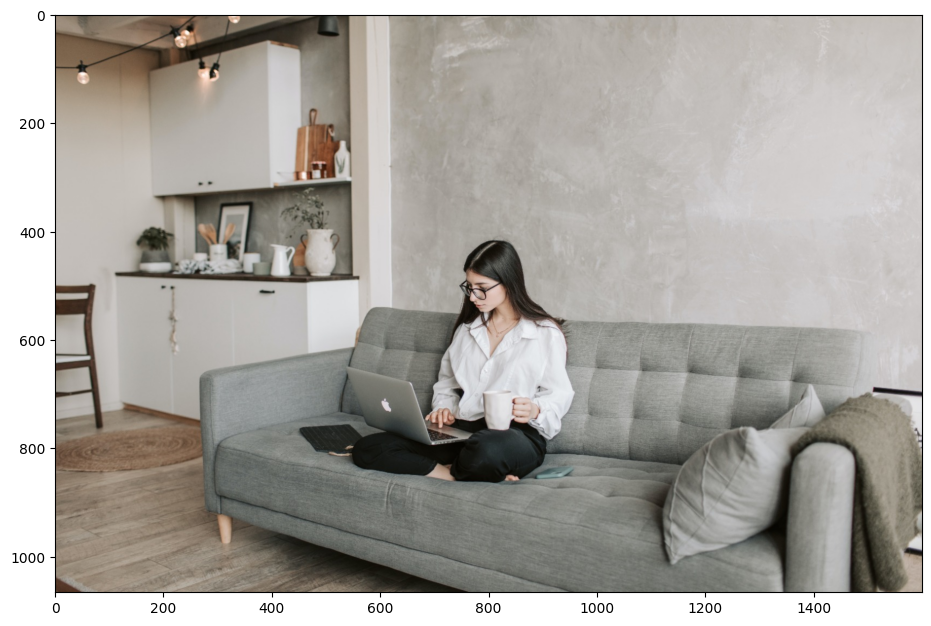

In [101]:
#show the image with matplotlib
#from IPython.display import Image
#Image ('../download.jpg')

import matplotlib.pyplot as plt
plt.figure(figsize=(15,7.5))
plt.imshow(im[..., ::-1]) #bgr to rgb



In [102]:
# Create config

cfg = get_cfg()
cfg.merge_from_file("C:/Users/saill/Desktop/detectron2_/configs/COCO-Detection/faster_rcnn_R_101_FPN_3x.yaml")
cfg.MODEL.ROI_HEADS.SCORE_TEST = 0.5 #set threshold for thid model
cfg.MODEL.WEIGHTS = "detectron2://COCO-Detection/faster_rcnn_R_101_FPN_3x/137851257/model_final_f6e8b1.pkl"


In [103]:
# Create predictor

cfg.MODEL.DEVICE = "cpu"

predictor = DefaultPredictor(cfg)

In [104]:
outputs = predictor(im)

In [94]:
print(outputs["instances"].pred_classes)
print(outputs["instances"].pred_boxes)

tensor([57, 75, 41, 75, 75, 58, 75, 26, 56, 41, 57, 57, 58, 57, 75, 59, 59, 56,
        60, 28, 58, 56, 56, 56, 58, 74, 60, 75, 75, 65, 41, 56, 75,  0, 56, 74,
        57, 56, 59, 75, 58, 45, 57, 74, 39, 57, 59])
Boxes(tensor([[ 338.5390,  847.7394, 1020.4004, 1304.0333],
        [ 141.6508,  568.6384,  170.6502,  609.0142],
        [  66.1889,  957.3992,   90.9147,  994.2402],
        [ 312.0231, 1051.8535,  382.1040, 1133.1512],
        [ 243.7646,  583.0605,  268.6029,  611.7497],
        [   2.7725,  443.3557,  155.4719,  609.4736],
        [  57.9134,  557.4697,  117.2943,  605.4828],
        [ 838.4232, 1259.6443, 1065.4189, 1545.2208],
        [   0.0000, 1310.2590,  519.6326, 1585.7704],
        [  92.9135,  948.3109,  118.2515,  990.6755],
        [  11.2473, 1314.7719,  481.3333, 1582.7325],
        [   0.0000, 1433.3882,  377.3702, 1597.6439],
        [ 240.9803,  567.4910,  270.3452,  612.3979],
        [ 184.2810,  913.6295,  485.9104, 1105.8198],
        [ 274.9419,  584.

<Figure size 1000x500 with 0 Axes>

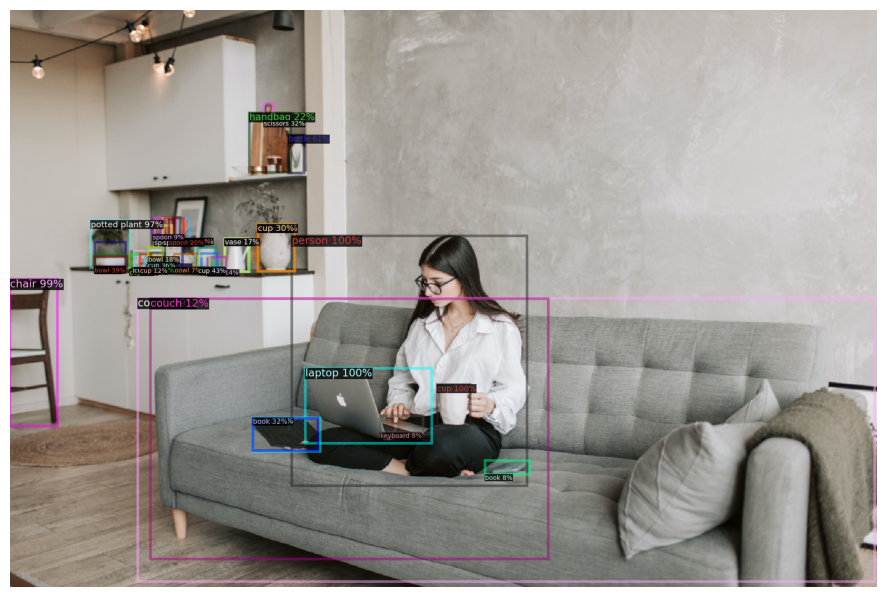

In [105]:
v = Visualizer(im[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=1.2)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

def cv2_imshow(im):
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(25,7.5)), plt.imshow(im), plt.axis('off');
plt.figure(figsize=(10,5))

cv2_imshow(out.get_image()[:, :, ::-1])

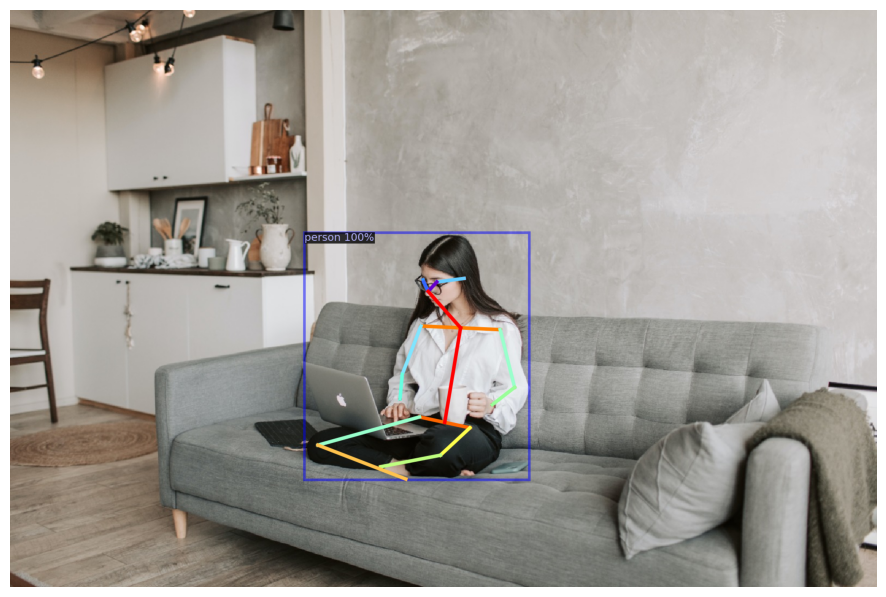

In [106]:
from detectron2 import model_zoo

cfg = get_cfg()
cfg.MODEL.DEVICE = "cpu"

cfg.merge_from_file(model_zoo.get_config_file("COCO-Keypoints/keypoint_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Keypoints/keypoint_rcnn_R_50_FPN_3x.yaml")

im = cv2.imread(image_path)

def cv2_imshow(im):
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(25,7.5)), plt.imshow(im), plt.axis('off');
    
predictor = DefaultPredictor(cfg)
outputs = predictor(im)

v = Visualizer(im[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=1.2)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
cv2_imshow(out.get_image()[:, :, ::-1])


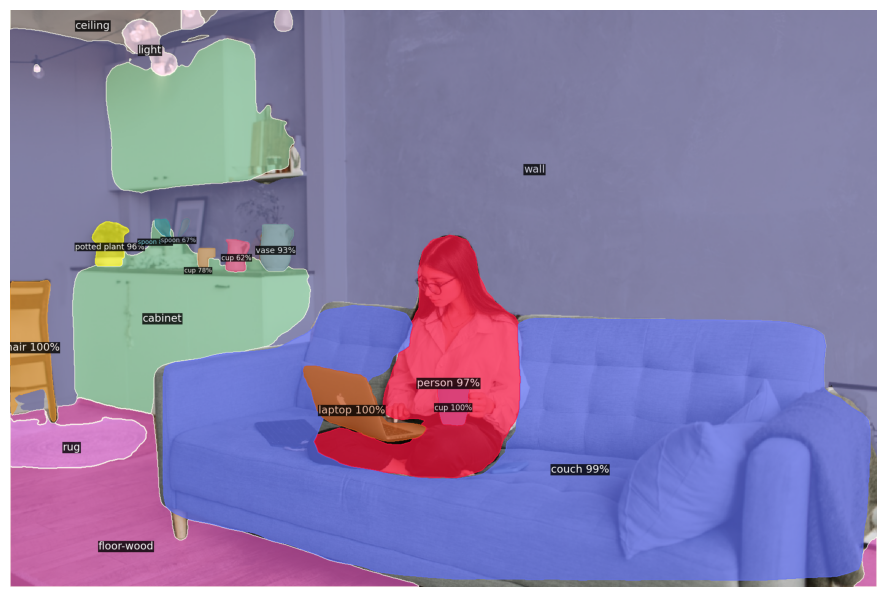

In [109]:
cfg = get_cfg()
cfg.MODEL.DEVICE = "cpu"

cfg.merge_from_file(model_zoo.get_config_file("COCO-PanopticSegmentation/panoptic_fpn_R_101_3x.yaml"))
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-PanopticSegmentation/panoptic_fpn_R_101_3x.yaml")

predictor = DefaultPredictor(cfg)
panoptic_seg, segments_info = predictor(im)["panoptic_seg"]

v = Visualizer(im[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=1.2)
out = v.draw_panoptic_seg_predictions(panoptic_seg.to("cpu"), segments_info)
cv2_imshow(out.get_image()[:, :, ::-1])

In [107]:
cfg = get_cfg()
cfg.MODEL.DEVICE = "cpu"

cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))

cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5

cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")

predictor = DefaultPredictor(cfg)
outputs = predictor(im)

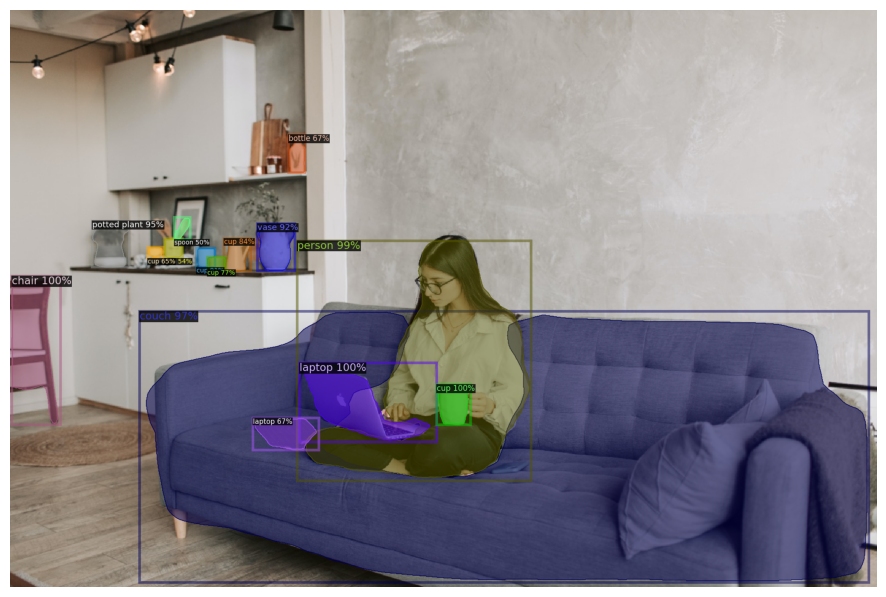

In [108]:
v = Visualizer(im[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=1.2)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
cv2_imshow(out.get_image()[:, :, ::-1])